# Analysis Notebook for Segment Handler v12.

This is a refinemnt of the v10 segment analysis notebook. This notebook focuses on the handling of the segment.

This notebook is refined due to the discovery of a new data leak that impacted the accuracy of the prior segment analysis.

## Abstract:

### The issues:

Artificial Intelligence (AI) currently faces three major issues:
-	Size: AI models are incredibly large (up to a couple billion parameters sometimes). This can require massive datacenters with specific and expensive hardware, incurring major energy costs.
-	Transparency: Little is known about how AI makes its computations. It is frequently referred to as a black box.
-	Limited modularity: While Ais can be configured with different settings (ex. amount of hidden layers), it is difficult to isolate issues or integrate different models together.


### Intent:

The goal of this project is to find a way to help counter these issues securely. The “Nexus” system focuses on 3 areas:
-	Maintaining accuracy despite having less nodes
-	Improve traceability of computations
-	Maximize modularity, potentially integrating various types of AI’s together


### The Nexus:

Using a specialized 'Judge' node, I will route specific queries to different 'segments,' each with their own specialty in a specific type of data. The selected segments will then load their nodes and run the computation. The returns of these segments will be merged into a final prediction. Eventually, this process may be chained together with different specialist groups across a pipeline, but that exceeds the original intent. 
This approach will theoretically address the three issues previously discussed. 
-	Size: By dynamically loading specialist segments, I hope to lower the amount of time and memory it takes to run a computation. Why load 100 nodes if only 25 is needed? Additionally, I hope to be able to 'prune' unnecessary nodes. If a node is needless space, then I will get rid of it.
-	Transparency: I will create a custom segment type to allow better tracing of computations (both visually and statistically). This may potentially reveal more about how AI works.
-	Modularity: By having various specialist segments, the modularity of this framework will be guaranteed. Why not train segments separately in parallel? With this framework it would be possible to swap different segments as needed, allowing for various specializations to be configured as needed. 
Overall, we will be sacrificing the raw efficiency and simplicity of modern neural networks to have a potentially flexible, specialized, and interpretable system.


### Current Focus: The individual segment


When I worked on v10, it focused on the development of the unique segment. My previous failures have led me to focus on this narrow scope, homing in on this specific aspect and eventually building up the full nexus. Developing a single segment will have its strengths. It could provide early insight into my computational method and help determine if I can reduce the number of nodes while maintaining accuracy.

### Potential Cons:

Potential issues include:

Training difficulty:
- Sparse activation: It is difficult to update all the weights needed when only a subset of the nodes learn
- Overfitting: The narrower domain could lead individual segments to have poor generalization skills
- Time complexity: The segment training involves both position and node weights. This could make time for training much more costly compared to a traditional model
- Node tracking: Tracking the nodes to determine which to prune can also be expensive

Risk:
- If the Judge node miscalculates or misroutes, the error could cascade and sharply impact performance
- If the Judge gets too complex then it could become a computationally heavy bottleneck 
- Data formatting: It would be necessary to have standardized inputs and outputs for each computation. For certain AI types, this could become costly to align
- Curse of Dimensionality: A feature of this framework is changing the number of dimensions used for computation as its graph based. Increasing the amount of dimensions can cause exponential growth in cost.



Careful practice can relieve many of these cons, but this will be difficult to implement compared to generic model pipelines which have become increasingly popular. Careful design and incremental scaling is required to avoid cascading errors.

### Potential applications:

This project is focused on addressing the previously discussed issues, but it is important to develop its potential applications. It is not intended to replace large language models, but the modularity could allow for interactions between different AI types. This could provide applications for AI agents. 

#### AI generated list of potential applications.

The following was generated by Claude.

##### Potential Segment Applications

A single trained segment is a compact, interpretable regression model for **structured, mixed-type tabular data**. Its core properties — stochastic signal propagation, online SGD, explicit path tracing, and post-training node pruning — make it best suited for the following:

- **Structured tabular regression / scoring** — The `PreProcessingNode` handles heterogeneous feature types natively: one-hot encoding for categoricals, min-max scaling for sequences and series, pass-through for scalars. This makes a segment a natural fit for datasets like student performance prediction, loan default scoring, or sensor health monitoring where inputs are mixed-type and well-structured.

- **Interpretable and auditable predictions** — Each forward pass records a `path_contributions` dictionary mapping every visited node to its exact scaled delta, input prediction weight, feature values, and relevance scores. This provides a literal, node-level trace of how each prediction was formed — directly useful in high-stakes or regulated domains (credit risk, medical triage scoring, academic assessment) where a model must explain its reasoning.

- **Online / incremental learning** — Training uses per-sample SGD with no batching. Weights, positions, and splitter relevance scores are updated immediately after every sample. This means a segment can be retrained or fine-tuned on a stream of incoming data without accumulating a full dataset, making it viable for live telemetry, adaptive pricing, or any scenario where concept drift occurs over time.

- **Low-resource and edge deployment** — After training, `_prune()` removes any node that was never activated during training, collapsing the graph to only its useful structure. The resulting model is serialized to a compact `.nexseg` JSON file with no framework dependencies beyond pure Python. This makes a trained segment deployable in environments without GPU resources or large ML frameworks.

- **Built-in feature importance analysis** — The `SplitterNode` maintains explicit, learned `signal_weights` (feature relevance scores) that are updated during training and are directly inspectable after the fact. Unlike post-hoc methods such as SHAP, this relevance is intrinsic to the model's computation and reflects which features the routing logic actively relies on — a natural tool for feature selection research or domain validation.

---

##### Potential Nexus Applications

The full Nexus system — `JudgeNode` routing across multiple trained segments, aggregated by a `HandlerNode` — is designed for scenarios where a **single monolithic model is either too expensive, too rigid, or too opaque**. The key properties of the Nexus are: dynamic specialist routing, independent segment training and swapping, and end-to-end traceability across the full prediction pipeline.

- **Mixture-of-Experts prediction across data domains** — The `JudgeNode` uses k-means-style clustering to route each input to the specialist segment(s) most relevant to that query's distribution. Segments can be trained independently on their respective domains, then composed into a Nexus without retraining. This achieves MoE-style efficiency (only a subset of parameters are active per inference) while keeping each expert interpretable.

- **Fraud detection and anomaly routing** — In fraud detection, different transaction types (e-commerce, wire transfers, cryptocurrency, in-person POS) have fundamentally different feature distributions and risk patterns. A Nexus could maintain one specialist segment per transaction class; the Judge routes each transaction to the correct specialist, and errors in one domain do not pollute the weights of another. Specialist segments can also be retrained or swapped when fraud patterns shift without touching the rest of the system.

- **Clinical decision support pipelines** — Patient records can be routed by presenting symptoms, test type, or specialty domain to the relevant diagnostic segment. Each segment's `path_contributions` traces are available at prediction time, providing clinicians with a full breakdown of which features drove the output — meeting interpretability requirements that black-box models typically fail. Segments can also be updated or replaced as clinical guidelines change, without rebuilding the entire pipeline.

- **Adaptive ensemble systems with hot-swap modularity** — Because each segment is a self-contained `.nexseg` file, the Nexus supports versioned segment libraries. A new specialization can be trained offline and inserted into a live Nexus with no downtime. Underperforming segments can be replaced, retrained in isolation, or retired. This is structurally different from re-training a monolithic network where all knowledge is entangled.

- **Mechanistic interpretability research** — The Nexus system as a whole is an explicit, inspectable computation graph: signal paths through individual segments are recorded, reviewer aggregations are transparent, and HandlerNode aggregation across segments uses a simple count-weighted average. This makes it a natural experimental platform for studying how learned graph topology relates to generalization, which routing decisions are stable vs. brittle, and how uncertainty propagates through a multi-stage prediction system — questions that are extremely difficult to study in opaque deep networks.
- **Multi-stage classification with coarse-to-fine routing** — The Judge-Segment topology maps naturally onto hierarchical classification problems. For example, in a 3D object-recognition pipeline, a first-stage `JudgeNode` can cluster inputs by broad *category* (vehicle, animal, furniture) using geometric partitioning of the feature space; each specialist segment then focuses on fine-grained identification *within* its category. Because each segment trains only on its partition, it develops highly specific internal topology — whereas a monolithic model must fit all classes simultaneously and dilutes its capacity on boundary cases. The segment's position-learning mechanism additionally orients its graph toward the regions of that category's feature space where discrimination is hardest, mirroring coarse-to-fine visual attention.

- **Adversarial and anomaly detection with adaptive segment retraining** — The signal-variance mechanism makes the architecture naturally sensitive to out-of-distribution inputs: when a sample produces high reviewer variance (no stable signal path converges), that variance is an unsupervised anomaly flag — no labeled anomaly data required. Combined with the ability to swap or retrain individual segments in isolation, this creates a continuously updatable detection system. A red-agent can generate new attack patterns; the affected segment is retrained against them without touching the others. See `v12/simulatedattackplan.txt` for a full design applying this pattern to network intrusion detection.

## The various nodes/components:

Below is the description of each node type.

#### Segment Nodes:
- Splitter Node: This node generates the initial signals and distributes that information to its nearest p% of processing nodes. It also calculates a feature relevance score for each feature to help give emphasis of certain features which may be relevant to the given dataset.

- Processing Node: These nodes are designed to be the main computational node in this neural net. Each processing node has a queue to store signals as they come in. These nodes use the current input as a feature, other feature weights, distance-based scaling and clamping to update a given prediction. They update a given prediction instead of generating a new one. To forward signals they save their signature in the signals visited nodes, and for each connected node calculate a weight for each node before randomly selecting one to forward to. This places emphasis on reviewer nodes and nodes further from the origin than others. In the case of a dead end, the signal will reset the list of the last 3 visited nodes. This list is a hard buffer preventing the visit of the past 3 visited nodes, but in the case of a dead end this list is reset allowing for back tracking of a given signal.

- Reviewer Node: The reviewer node is strictly mathematical without learning. It waits until each signal is received before reviewing the signals with inverse variance weighting so that signals with less variance (a more direct path) have higher weight. With this, it uses weighted sums which becomes the final prediction for that node.

#### Universal nodes/components:
- Signal: The signal is the key component in the processing. It is simply a class that saves the current prediction, variance, position, etc. 

- Preprocessing node: This node is implemented in segment handler as it is required for all preprocessing needed. When computing for a specific input, it will tokenize the categorical data and normalize the lists, tuples, or series. When handling full databases, it drops the removable columns, takes care of missing values, and then treats each row as an input to generate the database. Scalars themselves are not normalized.

#### Non-implemented System Nodes:
- Judge node: This node is designed to generate clusters from the data. This could allow for segments to specialize in a manner akin to Mixture of Experts models. Inputs will be distributed to needed segments accordingly.
- Handler node: Like a segment Reviewer node except the handler is designed to handle all reviewer node returns. However, this node uses a count of predictions, not weights.




## The Key Settings

 Outlined below are some of the key settings involved with the segment and what they do.

Segment specific: 

 - max x: This is the maximum x and y for the segment graph. It is the radius of the segment's arc and directly influences how many nodes can be loaded (as a max limit). More than that, it works with the power of dimensions and the density to directly influence how many nodes are loaded. 

 - target: This is the target column for the predictions. In the case of this demo, it is the exam score.

- connection percentage: This impacts how many nodes each node can connect to. For the splitter, it is a percentage based on the total amount of nodes, but for processing nodes it represents a percentage of 50 (so there can be a max of 50 connections given a high enough percentage). By default, I have this set to .1.

- density: This is the number of nodes that will attempt to be loaded as a percentage of the total area given the max x.

- dimensions: This is how many dimensions will be loaded. Higher dimensions will provide exponentially more nodes but will also be affected by the curse of dimensionality. By default, this is set to 2.

- classification: This is used for logging purposes. 4 is info level (minimal logs), 3 is warning info, 2 is error info, and 1 is full debug. By default, this is 4.

- segment ID: This is an identifier for the current segment. While its use is limited right now, it will have use when a full system is developed.

- Nexseg file: This is the file path to save the segment information. This allows the best segments to be saved and loaded in the future (untested).

- Dataset CSV: This is the path for the dataset. In this case it is Exam_Score_Prediction.csv.

Splitter: 

- Grad clip: This clamps the per feature relevance gradient to [-1,1]

- Weight clip: this clamps the per feature relevance weights to [-5, 5]

Processing:

- delta clip: This clamps each nodes scaled delta (its contribution) before it is added to the active prediction. By default, this is [-10, 10].

- pred clip: This clamps the running prediction to prevent prediction explosion and overflow. By default, this is [-1000000, 1000000].

- grad clip: This clamps the weight and position gradients. By default, this is [-1, 1].

- Weight clip: This clamps all the learned feature weights. By default, this is [-5, 5].

- min connections: This guarantees each processing has a certain number of connections regardless of connection percentage. By default, this is 3.

- position penalty: This is used to regularize the amount of movement. When the position gradient is calculated, this penalty applies based on the distance from the nodes original position preventing excessive movement and structural collapse. By default, this is .1.

- reviewer bonus: This multiplies a reviewer node's routing weight by a constant, so signals are biased towards the reviewer. By default, this is 3.

Training settings: 

- Weight LR: The weight learning rate is the base rate for how much the node feature weights can update. By default, this is .01.

- Position LR: The position learning rate is the base rate for how much the nodes can move. By default, this is set to .005 to prevent excessive movement.

- Splitter LR: The splitter learning rate is the base rate for the splitters feature relevance scoring system. By default, this is .01.

- LR decay: The learning rate decay decreased the learning rates for the above three over each epoch. By default, this is .85.

- Max Position Step: This is the hard cap on how far a node can move per update regardless of the gradient. It is a final safety. By default, this is 2.

- Convergence Threshold: This determines if early stopping is needed. Training will stop if the change in loss between consecutive epochs is below this threshold. By default, it is 1e-4.

- Plateau Threshold: Since reconnections can generate a lot of noise and interfere with learning, this threshold exists. If the range of the last 3 test errors are under this threshold percentage, then the plateau status is implemented (refer to training procedure below). By default, this is set to 3%.

- Plateau Position LR Scale: When plateau status is enabled, the position learning rate is multiplied by this. By default, this is set to .01. 




## The procedure for a segment:

The three parts to the segment handler is the initialization, training, and inference.



### Initialization:


In initialization, the handler will first check the max x and the dimensionality. It will first place a splitter node at the position tuple (1 for _ in range (dimensions)). Examples are (1,1) for 2 dimensions or (1,1,1) for 3 dimensions, etc. Then for the segment it will have n reviewers. The reviewers will be placed in hypercube corners and 1 coordinate at the max dimension. In a 2D circle this will be 3 reviewers with one at the (max x, 0), (0, max x), and at the 45-degree arc.

Next it must set up each processing node. The processing nodes cannot be at the splitter and reviewer positions. When run, the program will calculate the amount of needed processing nodes by calculating the max space * the density. Then the code will attempt to place nodes equidistant from each other at easy points. 

The final part will be to connect the nodes. Using the connection percentage, the code will go through each processing node having all of them compute the closest nodes who are further away from the origin than the given node. Then it will have the splitter connect to its nearest neighbors (ignoring distance from origin). It will also force reviewer connections since each reviewer must have at least one connection. 



In [1]:
# example initialization

# imports
import SegmentHandler
import time
import pandas as pd
import Components.NotebookLogger as NotebookLoggerModule

print("=" * 65)
print("  Segment Handler Analysis")
print("=" * 65)

# Load the dataset and prepare a sample for evaluation
DATASET_CSV = "Exam_Score_Prediction.csv"
TARGET_COL  = "exam_score"

logger = NotebookLoggerModule.NotebookLogger(
    f"segment_analysis_notebook_{int(time.time())}.log", log_level=4, console_level =4
)

dataset    = pd.read_csv(DATASET_CSV)
sample_raw = dataset.iloc[0].to_dict()
actual     = sample_raw.get(TARGET_COL)
logger.log(f"Evaluation sample loaded. Actual {TARGET_COL}: {actual}", 4, True)

# Initialize the Segment Handler
print("\n" + "─" * 22 + " Initializing New Segment " + "─" * 22)
handler = SegmentHandler.SegmentHandler(
    maxX=10, target=TARGET_COL, logger=logger,
    connection_percentage=0.1, density=0.8,
    dimensions=2, classification=4, segment_id=0
)
handler.initializeSegment()

print("\nSegment Handler initialized successfully.")
print(f"  Segment ID:    {handler.segment_id}")
print(f"  Target Column: {handler.target}")
print(f"  Max X:         {handler.max_x}")

  Segment Handler Analysis

────────────────────── Initializing New Segment ──────────────────────


Segment 0 Creating Nodes:   0%|          | 0/63 [00:00<?, ?it/s]

Segment 0 Connecting Nodes:   0%|          | 0/63 [00:00<?, ?it/s]


Segment Handler initialized successfully.
  Segment ID:    0
  Target Column: exam_score
  Max X:         10


### Graphical Representation of a new 2D segment (max x = 10)



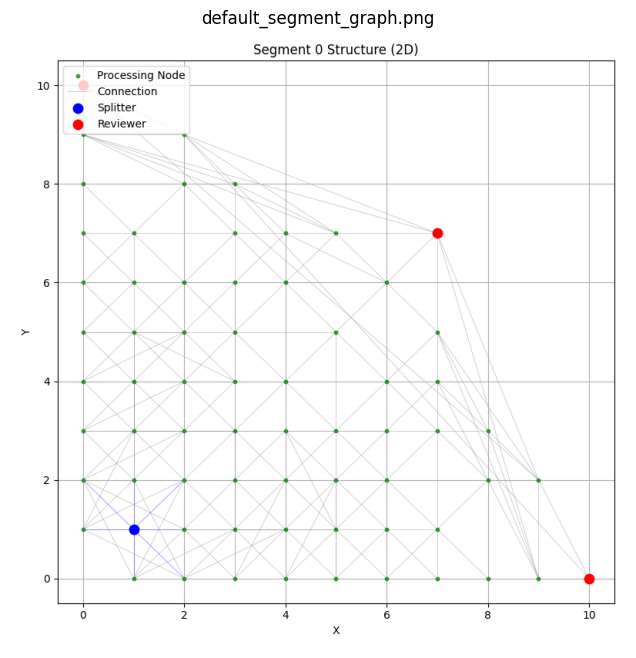

In [2]:
# Display the segment graph image
import matplotlib.pyplot as plt
img = plt.imread("default_segment_graph.png")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("default_segment_graph.png")
plt.show()

### Segment Training:


Given the complexity of training something like this, I will describe the abstract of how training is done and let Claude AI describe the more technical details. 

It begins by pre-processing the dataset and then generating a standard 80/20 train/test split. Then for each processing node, it will use the features to initialize a small-scale weight based on 1/(number of features). After doing this, the per epoch training procedure will begin. 

For each Epoch, it will begin by checking if learning has plateaued over the last three epochs by using the average test error. If the model is still learning, it will then begin calculating the optimal gradient for the weights of the processing nodes through running an inference loop for each sample. Then it will find the optimal gradient for the positions. If the positions do not allow enough learning and instead generate noise, their connections will be frozen, the position learning rate will drastically decrease, and the rest of the learning will be dedicated to weights and relevance scores.

It will continue this process until the max epoch limit is reached or if the early stopping threshold is reached. It will save the epoch with the lowest average test error score.




#### AI Generated Description — How Learning is Accomplished



Training in this system is a custom gradient descent loop over a stochastic signal-propagation graph. It is not a conventional neural network but shares many of the same underlying principles: a forward pass accumulates a prediction, a loss is computed, gradients are backpropagated through the recorded path, and parameters are updated. There are three distinct parameter types being learned simultaneously: **node weights**, **node positions**, and **splitter feature relevance scores**.

---

##### 1. Forward Pass (`_forward_segment`)

For each training sample, the forward pass begins at the `SplitterNode`. It generates one `Signal` per connected processing node. Each signal is initialized with:
- `prediction = 0.0` — a running accumulator that each node will modify
- `input` — the full preprocessed feature dict for the sample
- `feature_relevance` — per-feature weights currently held by the splitter (`signal_weights`)
- `variance = 0.0` — a running accumulator of absolute deltas, used later for inverse-variance weighting
- `signal_life = (max_x² × 0.8)` — a TTL that decrements each time the signal is received by a node
- `path_contributions = {}` — a dict keyed by node `id`, recording each node's contribution for backprop

Signals are dispatched to the splitter's connected nodes, then the main processing loop runs (up to 500 iterations). Each iteration walks every `ProcessingNode`. If a node holds a signal it calls `train_process_signal()`:

```
weighted_sum = prediction × w_pred
             + Σ (value_i × w_i × rel_i)   for each feature i

scaled_delta = clip(weighted_sum / (1 + dist_to_origin), −10, 10)

signal.prediction  += scaled_delta
signal.variance    += |scaled_delta|
```

The distance scaling `1 / (1 + dist)` means nodes closer to the origin (early in the graph) contribute larger deltas, while nodes near the boundary contribute smaller, more refined corrections. This creates a coarse-to-fine prediction refinement as the signal travels outward.

After processing, the node records its full contribution into `signal.path_contributions[id(self)]` — storing the node reference, the `scaled_delta`, the raw `weighted_sum`, the distance, per-feature details `(value, weight, relevance)`, the `input_prediction` weight, and the prediction value *before* this node's update. This snapshot is what makes backpropagation possible without a traditional computation graph.

The node then calls `forward_signal()` to route the signal. Routing is stochastic: each candidate node is assigned a weight and one is selected via `random.choices`. The weight function is:
- **ReviewerNodes**: `distance_to_origin × 3.0` (tripled bonus, direction-independent)
- **ProcessingNodes**: `distance_to_origin × (1 + max(0, outward_alignment))` where `outward_alignment` is the dot product of the movement direction with the node's outward unit vector

This biases signals toward the arc boundary and toward reviewer nodes, while still being non-deterministic. A rolling buffer of the last 3 visited nodes (`recent_visited`) prevents immediate backtracking. If no viable node exists (dead end), this buffer is cleared and the signal is rerouted from its current position.

The loop ends when all signals are either expired or collected by a `ReviewerNode`. Upon collection, `ReviewerNode.receive_signal()` resets the signal's `signal_life` to 5 and marks `signal.collected = True`, effectively keeping it alive just long enough to be reviewed.

At the end of the forward pass, each `ReviewerNode` calls `review_signals()`, which computes an **inverse-variance weighted average** of all collected signals:

```
w_i    = 1 / max(variance_i, 1e-9)
output = Σ(prediction_i × w_i) / Σ(w_i)
```

Signals with a lower accumulated variance — meaning they took a more direct or less noisy path — carry more weight in the final prediction. This acts as a soft selection for high-confidence paths.

---

##### 2. Backpropagation

A single MSE loss gradient is computed for each reviewer's output:

```
dL/d(reviewer_pred) = 2 × (reviewer_pred − target)
```

This gradient is distributed back through the reviewer's collected signals proportionally to their inverse-variance weights:

```
dL/d(signal_pred_i) = dL/d(reviewer_pred) × (w_i / Σw)
```

Each signal then walks its `path_contributions` dict and distributes this gradient to the nodes on its path.

**Weight gradients** (accumulated in `node.weight_gradients`):

For each feature `j` at node `k`:
```
dL/dw_j_k = dL/d(pred_i) × value_j × rel_j × (1 / (1 + dist_k))
```
For the `input_prediction` weight at node `k`:
```
dL/dw_pred_k = dL/d(pred_i) × prev_prediction × (1 / (1 + dist_k))
```
All gradient elements are clipped to `[−1, 1]` before accumulation.

**Position gradients** (accumulated in `node.position_gradient`):

The distance term `1 / (1 + dist)` is differentiable with respect to position. For coordinate `j` of node `k`:
```
d(scaled_delta)/d(pos_j) = raw_delta × (−pos_j / (dist × (1 + dist)²))

dL/d(pos_j) = dL/d(pred_i) × raw_delta × (−pos_j / (dist × (1 + dist)²))
```
A **displacement penalty** is then added before the update step:
```
dL/d(pos_j) += POSITION_PENALTY × (pos_j − original_pos_j)    [= 0.1 × displacement]
```
This is the gradient of an L2 regularizer `λ‖pos − pos_original‖²` with `λ = 0.1`. It pulls each node back toward its initialized position proportionally to how far it has drifted, preventing topology collapse.

**Splitter feature relevance gradients** (`_backprop_splitter`):

The splitter's `signal_weights[feat]` flow into every node on the signal's path as `rel_feat`. The chain rule across all nodes on the path gives:
```
dL/d(rel_feat) = Σ_k [ dL/d(pred_i) × value_feat × w_feat_k / (1 + dist_k) ]
```

---

##### 3. Parameter Updates

After backpropagation for each sample, the three sets of parameters are updated immediately (online/SGD, not batched):

**Node weights**: `w_j -= lr_w × grad_j`, then clipped to `[−5, 5]`

**Node positions**: `pos_j -= lr_p × (grad_j + penalty_j)`, clamped to a max step of `2.0`, then projected back onto the quarter-circle arc if the new position falls outside it (coordinates clamped to `[0, max_x]`, then rescaled to radius `max_x` if needed). After positions shift, each node **rebuilds its connections** by re-running `connect_nearest_nodes()` against all processing nodes and reviewers.

**Splitter feature relevance**: `rel_feat -= lr_s × grad_feat`, clipped to `[−5, 5]`

All three learning rates decay each epoch by a factor of `0.85^epoch`.

---

##### 4. Plateau Detection and Connection Freezing

At the start of each epoch, the last 3 recorded test-set average % errors are examined. If the range `(max − min) < 3%`, the model is considered to be on a plateau. In this state:
- `lr_p` is scaled down to `1%` of its already-decayed value (nearly freezing position movement)
- `freeze_connections=True` is passed to `_epoch()`, so the topology is not rebuilt after position updates

This prevents the connectivity graph from thrashing when the model has stopped improving, allowing weight and feature-relevance refinement to continue in a stable topology.

Early stopping (unrelated to plateau) triggers when the change in training loss between consecutive epochs falls below `1e-4`.

---

##### 5. Best Model Tracking and Pruning

After each epoch, the full test split is evaluated for average % error using `_eval_avg_error()`. If this improves over the previous best, the current segment state (all node weights, positions, and connections) is serialized to `segment_{id}.nexseg` as JSON.

After all epochs complete, `_prune()` removes any `ProcessingNode` whose `activation_count == 0` — nodes that were never reached by any signal during training. Their dangling connections are also removed from surviving nodes.

Finally, the best-epoch model is restored from `.nexseg` and evaluated on the full test split, computing: MAE, RMSE, R², MAPE, within-5/10/20% accuracy, direction accuracy, and precision/recall/F1 (via median split). Results are appended to `error-epoch.csv`.

### Segment Inference



Like above, I will write the abstract for how model inference works. Claude AI will describe the full technical procedure.

Fundamentally, the inference works in a similar way to the training. When the segment is given a specific input, the preprocessing node will process the data into a format suitable for the segment inference (note: this is not included in the inference function, it must be called separately). The data will be given to the splitter which will generate and distribute the signals to the connected nodes. Each node with a signal will then process that signal altering the active prediction of the signal before using a weighted random to forward the signal to another node. Eventually, the signals will all die or be received by a reviewer node which will compute its final prediction. Note that there is currently no way to have a final prediction from the reviewers. That would be implemented in the full system. For analysis purposes, the average of the reviewers' predictions is used.



#### AI Generated Description — Inference Procedure



Inference in `segmentInfer()` is structurally identical to the training forward pass but stripped of all gradient machinery. No weights, positions, or feature relevance scores are modified. The method takes a pre-processed input dict (the caller's responsibility to prepare via `PreProcessingNode`) and returns a list of per-reviewer prediction reports.

---

##### 1. State Reset

Before any signals are generated, all residual state from prior runs is cleared:
- Every `ProcessingNode` has its `signal` and `signal_queue` set to `None`/`[]` via `clear_signals()`
- Every `ReviewerNode` has its `signals` list emptied

This ensures no stale signal from a previous inference contaminates the current pass.

---

##### 2. Signal Generation and Dispatch

The `SplitterNode.process()` call computes the current feature relevance scores from its learned `signal_weights` and generates one `Signal` per connected node. Each signal is initialized with:
- `prediction = 0.0`
- `input` — the pre-processed feature dict
- `feature_relevance` — the splitter's current `signal_weights` (learned during training)
- `variance = 0.0`
- `signal_life = (max_x² × 0.8)`
- `path_contributions = {}` — allocated but never written to during inference

Signals are then dispatched one-to-one to the splitter's connected processing nodes via `node.receive_signal(signal)`.

---

##### 3. Processing Loop

The main loop runs for up to 500 iterations. Each iteration walks every `ProcessingNode`. If a node holds a signal, it calls `process_signal()` — the inference-mode counterpart to `train_process_signal()`. The math is identical:

```
weighted_sum = prediction × w_pred
             + Σ (value_i × w_i × rel_i)   for each feature i

scaled_delta = clip(weighted_sum / (1 + dist_to_origin), −10, 10)

signal.prediction += scaled_delta
signal.variance   += |scaled_delta|
```

The critical difference from training: **`path_contributions` is never populated**. There is nothing to backpropagate through, so the contribution recording step is simply absent. `activation_count` is also not incremented during inference.

After processing, the node calls `forward_signal()`, which is unchanged from training — the same stochastic routing with outward alignment bias, the reviewer bonus (`×3.0`), and the `recent_visited` anti-cycle buffer of size 3.

The loop terminates when every signal is either expired (`signal_life ≤ 0`) or has been collected by a `ReviewerNode` (`signal.collected == True`). A hard cap of 500 iterations prevents infinite loops if signals get trapped.

---

##### 4. Reviewer Aggregation

When a signal reaches a `ReviewerNode`, `receive_signal()` resets its `signal_life` to 5 and marks it `collected = True`. After the loop ends, each reviewer calls `review_signals()`, which computes the same inverse-variance weighted average used in training:

```
w_i    = 1 / max(variance_i, 1e-9)
output = Σ(prediction_i × w_i) / Σ(w_i)
```

If no valid signals reached a reviewer (all expired before arrival), `review_signals()` returns `None` and that reviewer produces no report.

---

##### 5. Return Value

`segmentInfer()` returns a list of report dicts, one per reviewer that produced a valid prediction:

```python
{'id': segment_id, 'prediction': float, 'reviewer_position': tuple}
```

In the full system this list would be passed to a `HandlerNode`, which aggregates across all segments. As that is not yet implemented, the analysis notebook uses a simple average across all reviewer predictions as a stand-in final output.

## DEMO:

### The training data:
I am using a dataset from Kaggle called Exam Score Prediction. It is a csv with the following information:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('Exam_Score_Prediction.csv')

print("\nFirst 5 rows of the dataset:")
data.head()



First 5 rows of the dataset:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:

print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


### Pre training inference:
I will demonstrate the results when running this segment using a random input row before training is done. The result will be random noise but will serve as a point of comparison.

In [5]:
import random
import Components.PreProcessingNode as Preprocessor
random.seed(42)  # For reproducibility
if handler is None:
    raise Exception("Segment Handler must be initialized.")

preprocessor = Preprocessor.PreProcesingNode(Logger=logger, logger_classification=4)
_ = preprocessor.process_dataset(dataset.copy())   # warm up vocabulary

print("--- Pre-Training Inference ---")
pre_input   = preprocessor.process_data(sample_raw.copy())
pre_reports = handler.segmentInfer(pre_input, loud=True)
logger.log(f"Pre-training results: {len(pre_reports)} reviewer report(s).", 4, True)

print(f"\n{'Reviewer Position':<25} {'Prediction':>12} {'Actual':>12} {'Error %':>10}")
print("-" * 62)
err_sum = 0
for r in pre_reports:
    pred = r['prediction']
    err  = abs(pred - actual) / abs(actual) * 100 if actual else 0
    err_sum += err
    print(f"{str(r['reviewer_position']):<25} {pred:>12.4f} {actual:>12.4f} {err:>10.2f}")

print(f"Average Pre-Training Error: {err_sum / len(pre_reports):.4f}%")

Pre-processing dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

[INFO]: Evaluation sample loaded. Actual exam_score: 58.9
[INFO]: [Main]: Calculated 63 unique node positions with 0 breaks to avoid duplicates.
[INFO]: [Main]: Segment 0 - Reviewer (10, 0) connected to 4/63 processing nodes.
[INFO]: [Main]: Rendering Segment 0 structure.
[INFO]: [Main]: Default segment graph saved → default_segment_graph.png
--- Pre-Training Inference ---
[INFO]: [PreProcessingNode]: Pre-processing complete.


Segment 0 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

[INFO]: [Main]: Generated 7 signals, Splitter has 7 connected nodes
[INFO]: [Main]: Dispatched signals to processing nodes.
[INFO]: [Main]: Signals processing complete after 5 iterations.

Reviewer Position           Prediction       Actual    Error %
--------------------------------------------------------------
(10, 0)                        90.0000      58.9000      52.80
(7, 7)                         80.0000      58.9000      35.82
(0, 10)                        81.6194      58.9000      38.57
Average Pre-Training Error: 42.3992%


### Training:
Below is where I demonstrate the training of the model with 20 epochs.

In [6]:
print("--- Training ---")

epoch_history = handler.train(dataset, epoch_count=20)

import math
if epoch_history:
    best_e = min(
        epoch_history,
        key=lambda e: (
            sum(v for v in e['errors'].values() if not math.isnan(v)) /
            max(1, sum(1 for v in e['errors'].values() if not math.isnan(v)))
        )
    )
    best_train_vals = [v for v in best_e['errors'].values() if not math.isnan(v)]
    best_train_avg  = sum(best_train_vals) / len(best_train_vals) if best_train_vals else float('nan')
    best_test_avg   = best_e.get('test_avg_error', float('nan'))

    print("\n--- Best Epoch Summary ---")
    print(f"{'Metric':<25} {'Value':>15}")
    print("-" * 42)
    print(f"{'Best Epoch':<25} {str(best_e['epoch']):>15}")
    print(f"{'Training Loss':<25} {best_e['loss']:>15.6f}")
    print(f"{'Train Avg Error %':<25} {f'{best_train_avg:.2f}%' if not math.isnan(best_train_avg) else '—':>15}")
    print(f"{'Test Avg Error %':<25} {f'{best_test_avg:.2f}%'  if not math.isnan(best_test_avg)  else '—':>15}")

    

--- Training ---


Pre-processing dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

[INFO]: Pre-training results: 3 reviewer report(s).
[INFO]: [Main]: Training Step 1: Processing dataset.


Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20:   0%|          | 0/16000 [00:00<?, ?it/s]

...

Epoch 19/20:   0%|          | 0/16000 [00:00<?, ?it/s]

Segment 0 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/16000 [00:00<?, ?it/s]

Segment 0 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

[INFO]: [Main]: Loaded segment 0 from 'segment_0.nexseg' (63 nodes, 3 reviewers).
[INFO]: [Main]: Evaluating on 4000 test samples…
[INFO]: [Main]: Test Metrics | MAE=15.8701  RMSE=19.4674  R²=-0.0475  MAPE=28.45%  Acc@10%=21.8%  F1=0.5633
[INFO]: [Main]: Run metrics appended to error-epoch.csv.

--- Best Epoch Summary ---
Metric                              Value
------------------------------------------
Best Epoch                             20
Training Loss                  612.001089
Train Avg Error %                   2.58%
Test Avg Error %                   29.64%


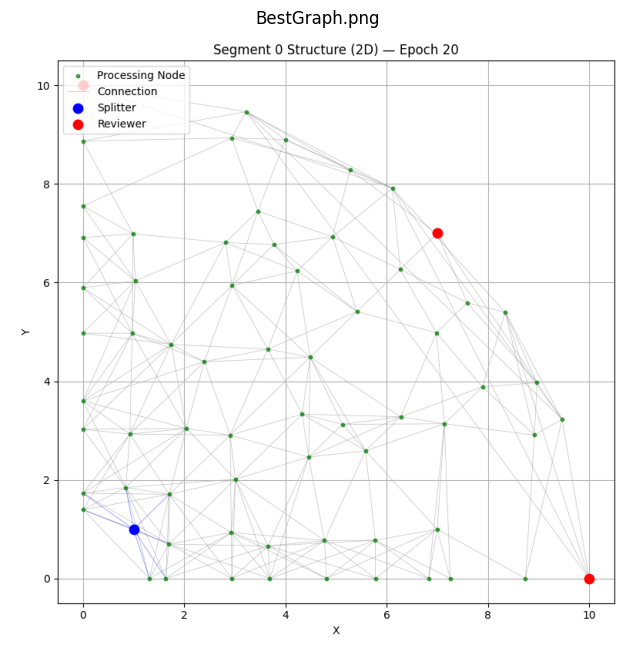

In [7]:
# Show the new position graph image
handler.visualize_2d('BestGraph', best_e['epoch'])
import matplotlib.pyplot as plt
img = plt.imread("BestGraph.png")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("BestGraph.png")
plt.show()

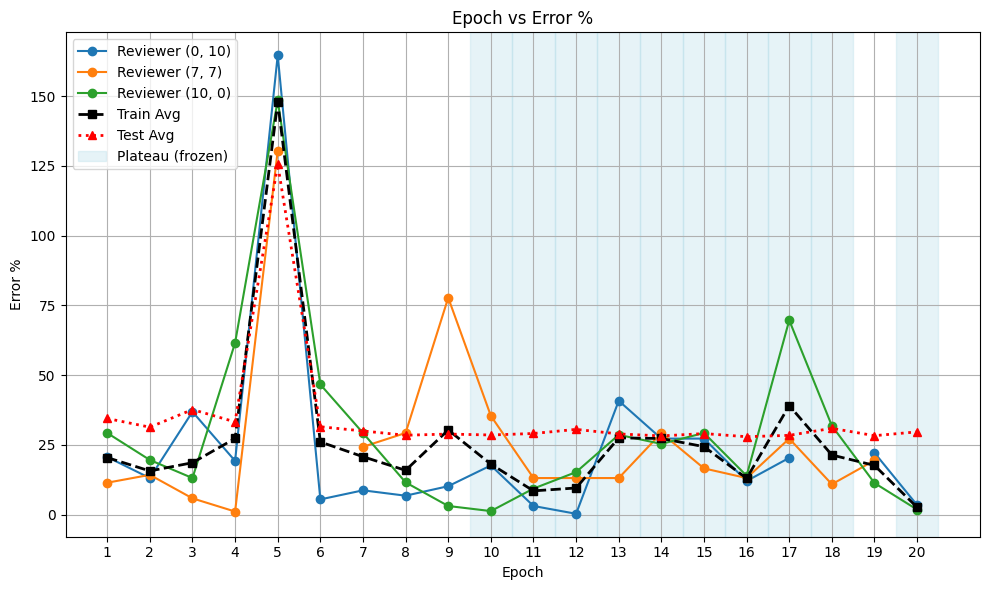

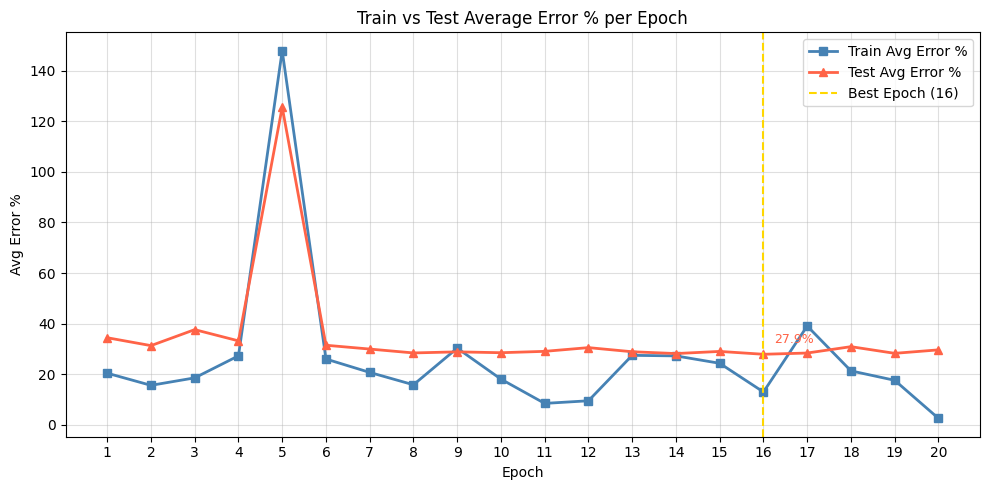

In [8]:
# Here we can see how the different error metrics evolved over the epochs, and which epoch had the best performance on average across all reviewers

if epoch_history:
    import matplotlib.pyplot as plt

    epochs       = [e['epoch'] for e in epoch_history]
    all_positions = sorted({pos for e in epoch_history for pos in e['errors']})

    fig, ax = plt.subplots(figsize=(10, 6))
    for pos in all_positions:
        errs = [e['errors'].get(pos, float('nan')) for e in epoch_history]
        ax.plot(epochs, errs, marker='o', label=f"Reviewer {pos}")

    # Train avg error (across reviewers) and test avg error
    avg_errs = []
    for e in epoch_history:
        vals = [v for v in e['errors'].values() if not math.isnan(v)]
        avg_errs.append(sum(vals) / len(vals) if vals else float('nan'))
    ax.plot(epochs, avg_errs, marker='s', linestyle='--', linewidth=2,
            color='black', label='Train Avg')

    test_errs = [e.get('test_avg_error', float('nan')) for e in epoch_history]
    ax.plot(epochs, test_errs, marker='^', linestyle=':', linewidth=2,
            color='red', label='Test Avg')

    # Shade plateau epochs
    for e in epoch_history:
        if e.get('plateau'):
            ax.axvspan(e['epoch'] - 0.5, e['epoch'] + 0.5,
                        color='lightblue', alpha=0.3,
                        label='Plateau (frozen)' if e['epoch'] == next(
                            x['epoch'] for x in epoch_history if x.get('plateau')
                        ) else None)

    ax.set_title("Epoch vs Error %")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error %")
    ax.set_xticks(epochs)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    fig.savefig("epoch_error.png")
    plt.show()

    # ── Train vs Test avg error graph ─────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(epochs, avg_errs, marker='s', linewidth=2, color='steelblue', label='Train Avg Error %')
    ax2.plot(epochs, test_errs, marker='^', linewidth=2, color='tomato',   label='Test Avg Error %')

    # Mark best epoch (lowest test avg)
    valid_test = [(i, v) for i, v in enumerate(test_errs) if not math.isnan(v)]
    if valid_test:
        best_i, best_v = min(valid_test, key=lambda x: x[1])
        ax2.axvline(x=epochs[best_i], color='gold', linestyle='--', linewidth=1.5,
                    label=f"Best Epoch ({epochs[best_i]})")
        ax2.annotate(f"{best_v:.1f}%", xy=(epochs[best_i], best_v),
                        xytext=(8, 8), textcoords='offset points', fontsize=9, color='tomato')

    ax2.set_title("Train vs Test Average Error % per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Avg Error %")
    ax2.set_xticks(epochs)
    ax2.legend()
    ax2.grid(True, alpha=0.4)
    fig2.tight_layout()
    fig2.savefig("epoch_train_test_error.png")
    plt.show()

### Post Test Inference and Summary

In [9]:

from rich.console import Console
from rich.table import Table
from rich import box
from rich.rule import Rule

console = Console()

# ── Run post-training inference ────────────────────────────────────────────
post_input   = preprocessor.process_data(sample_raw.copy())
post_reports = handler.segmentInfer(post_input, loud=False)

pre_map  = {r['reviewer_position']: r['prediction'] for r in pre_reports}
post_map = {r['reviewer_position']: r['prediction'] for r in post_reports}
all_pos  = sorted(set(pre_map) | set(post_map), key=lambda p: (p[0], p[1]))

def _fmt(val, dec=4):
    try:
        fv = float(val)
        return f"{fv:.{dec}f}" if not math.isnan(fv) else "—"
    except (TypeError, ValueError):
        return str(val) if val else "—"

def _err_pct(pred):
    if pred is None or actual is None or actual == 0:
        return float('nan')
    return abs(pred - actual) / abs(actual) * 100.0

def _err(pred, dec=2):
    v = _err_pct(pred)
    return f"{v:.{dec}f}%" if not math.isnan(v) else "—"

# ── Reviewer comparison table ──────────────────────────────────────────────
console.print(Rule("[bold cyan]Post-Training Inference Report[/bold cyan]", style="cyan"))

cmp_table = Table(
    title=f"Reviewer Predictions vs Actual  (actual = {_fmt(actual)})",
    box=box.ROUNDED, border_style="cyan", show_lines=True,
)
cols = [
    ("Reviewer",        "bold white",   "left"),
    ("Pre-Train Pred",  "yellow",       "right"),
    ("Post-Train Pred", "bright_green", "right"),
    ("Actual",          "bold white",   "right"),
    ("Pre Err %",       "red",          "right"),
    ("Post Err %",      "green",        "right"),
]
for name, style, justify in cols:
    cmp_table.add_column(name, style=style, justify=justify)

pre_errs, post_errs = [], []
best_post_err = min(
    (_err_pct(post_map.get(p)) for p in all_pos
     if not math.isnan(_err_pct(post_map.get(p)))),
    default=float('nan')
)

for pos in all_pos:
    pre_pred  = pre_map.get(pos)
    post_pred = post_map.get(pos)
    post_v    = _err_pct(post_pred)

    post_err_str = _err(post_pred)
    if not math.isnan(post_v) and post_v == best_post_err:
        post_err_str = f"[bold bright_green]{post_err_str}[/]"

    cmp_table.add_row(
        str(pos),
        _fmt(pre_pred), _fmt(post_pred), _fmt(actual),
        _err(pre_pred), post_err_str,
    )
    pv = _err_pct(pre_pred)
    if not math.isnan(pv):    pre_errs.append(pv)
    if not math.isnan(post_v): post_errs.append(post_v)

pre_avg  = sum(pre_errs)  / len(pre_errs)  if pre_errs  else float('nan')
post_avg = sum(post_errs) / len(post_errs) if post_errs else float('nan')
pre_avg_str  = f"[red]{pre_avg:.2f}%[/red]"   if not math.isnan(pre_avg)  else "—"
post_avg_str = f"[bright_green]{post_avg:.2f}%[/bright_green]" if not math.isnan(post_avg) else "—"

cmp_table.add_section()
cmp_table.add_row(
    "[bold]Average[/bold]", "—", "—", _fmt(actual),
    pre_avg_str, post_avg_str,
)
console.print(cmp_table)

# ── Training summary ───────────────────────────────────────────────────────
if epoch_history:
    best_e = min(
        epoch_history,
        key=lambda e: e.get('test_avg_error', float('inf'))
    )
    best_test = best_e.get('test_avg_error', float('nan'))

    summary = Table(
        title="Training Summary",
        box=box.SIMPLE_HEAVY, border_style="yellow", show_lines=False,
    )
    summary.add_column("Metric",  style="bold white", justify="left")
    summary.add_column("Value",   style="bright_yellow", justify="right")

    summary.add_row("Epochs run",          str(len(epoch_history)))
    summary.add_row("Best epoch",          str(best_e['epoch']))
    summary.add_row("Best test avg err %", f"{best_test:.2f}%" if not math.isnan(best_test) else "—")
    summary.add_row("Post-train avg err %",f"{post_avg:.2f}%"  if not math.isnan(post_avg)  else "—")
    improvement = pre_avg - post_avg if not math.isnan(pre_avg) and not math.isnan(post_avg) else float('nan')
    summary.add_row(
        "Improvement (pre → post)",
        f"[bright_green]↓ {improvement:.2f}%[/]" if not math.isnan(improvement) else "—"
    )
    console.print(summary)


Segment 0 Inference:   0%|          | 0/3 [00:00<?, ?it/s]

───────────────────────────────────────── Post-Training Inference Report ──────────────────────────────────────────

                Reviewer Predictions vs Actual  (actual = 58.9000)                
╭──────────┬────────────────┬─────────────────┬─────────┬───────────┬────────────╮
│ Reviewer │ Pre-Train Pred │ Post-Train Pred │  Actual │ Pre Err % │ Post Err % │
├──────────┼────────────────┼─────────────────┼─────────┼───────────┼────────────┤
│ (0, 10)  │        81.6194 │         84.7534 │ 58.9000 │    38.57% │     43.89% │
├──────────┼────────────────┼─────────────────┼─────────┼───────────┼────────────┤
│ (7, 7)   │        80.0000 │         74.6667 │ 58.9000 │    35.82% │     26.77% │
├──────────┼────────────────┼─────────────────┼─────────┼───────────┼────────────┤
│ (10, 0)  │        90.0000 │         80.0000 │ 58.9000 │    52.80% │     35.82% │
├──────────┼────────────────┼─────────────────┼─────────┼───────────┼────────────┤
│ Average  │              — │               — │ 58.9000 │    42.40% │     35.50% │
╰──────────┴────────────────┴─────────────────┴─────────┴───────────┴────────────╯

           Training Summary           
                                      
  Metric                       Value  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Epochs run                      20  
  Best epoch                      16  
  Best test avg err %         27.90%  
  Post-train avg err %        35.50%  
  Improvement (pre → post)   ↓ 6.90%  
                                      

A slight improvement from before training. While the error has only gone down ~7%, it is a sign that this architecture can learn and improve (even with a max X of only 10).

## Comparing to other models

To better understand how my models compare to other models I asked Claude Code to generate the code for various established AI models. All were given the same train-test split and have the same metrics.

In [2]:
"""
import comparisons.ComparisonManager as CompMgr
import Components.NotebookLogger as LoggerModule
import time
import Components.RichConsole as RichConsole
import pandas as pd
logger = LoggerModule.NotebookLogger('logs', log_level=4, console_level=4)
#logger = RichConsole.RichLogger(log_level=4, console_level=4, filename=f"segment_analysis_notebook_{int(time.time())}.log")
manager = CompMgr.ComparisonManager(logger=logger)
dataset = pd.read_csv("Exam_Score_Prediction.csv")
target  = "exam_score"
epochs  = 20
max_x   = [5, 10, 15, 20, 25, 30, 35, 40]

# Dedicated output file + run_system=False: this notebook only evaluates the
# standalone SegmentHandler, so it must never write into comparison_results.csv
# (the file v12Analysis.ipynb reads for the full SystemHandler comparison) and
# must never spend hours retraining the system. output_csv also changes the
# checkpoint job-hash, so this run can't pick up a stale/incompatible checkpoint
# from a previous (pre-leak-fix) run of this same cell.
manager.run_all(
    dataset        = dataset,
    target         = target,
    epoch_count    = epochs,
    segment_max_x  = max_x,
    run_segment    = True,
    run_cnn        = True,
    run_linear     = True,
    run_knn        = True,
    run_rf         = True,
    run_xgb        = True,
    run_mlp        = True,
    run_system     = False,
    output_csv     = "segment_comparison_results.csv",
)
"""
#This would be the code run, but since my laptop too weak it will be off loaded to a cloud server
#this is the code used

'\nimport comparisons.ComparisonManager as CompMgr\nimport Components.NotebookLogger as LoggerModule\nimport pandas as pd\nlogger = LoggerModule.NotebookLogger(\'logs\', log_level=4, console_level=4)\nmanager = CompMgr.ComparisonManager(logger=logger)\ndataset = pd.read_csv("Exam_Score_Prediction.csv")\ntarget  = "exam_score"\nepochs  = 20\nmax_x   = [5, 10, 15, 20, 25]\n\n# Dedicated output file + run_system=False: this notebook only evaluates the\n# standalone SegmentHandler, so it must never write into comparison_results.csv\n# (the file v12Analysis.ipynb reads for the full SystemHandler comparison) and\n# must never spend hours retraining the system. output_csv also changes the\n# checkpoint job-hash, so this run can\'t pick up a stale/incompatible checkpoint\n# from a previous (pre-leak-fix) run of this same cell.\nmanager.run_all(\n    dataset        = dataset,\n    target         = target,\n    epoch_count    = epochs,\n    segment_max_x  = max_x,\n    run_segment    = True,\n  

### Comparison Results Analysis:

In [15]:
results = pd.read_csv("segment_comparison_results.csv")
print("\nComparison results loaded from 'segment_comparison_results.csv':")
results.head()


Comparison results loaded from 'segment_comparison_results.csv':


,timestamp,run_id,model_name,model_config,target,n_features,n_train,n_test,epoch_count,train_time_sec,...,recall,f1,tp,fp,fn,tn,best_epoch,best_test_error_pct,related_train_error_pct,notes
0,2026-06-24 09:13:44,20260623_222221,CNN,"filters=8,kernel=3,conv_layers=1,dense=[64, 32...",exam_score,31,16000,4000,20,956.4166,...,0.000000,NaN,0,0,2007,1993,7.0,30.706487,30.870103,pure-python backprop
1,2026-06-24 09:13:44,20260623_222221,SegmentHandler,"max_x=5,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,259.8623,...,0.000000,NaN,0,0,2007,1993,5.0,32.327300,35.379600,"max_x=5,dim=2"
2,2026-06-24 09:13:44,20260623_222221,SegmentHandler,"max_x=10,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,1583.3205,...,0.176881,0.278759,355,185,1652,1808,9.0,28.763800,18.557000,"max_x=10,dim=2"
3,2026-06-24 09:13:44,20260623_222221,SegmentHandler,"max_x=15,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,5247.0798,...,0.920279,0.796292,1847,785,160,1208,20.0,21.185000,25.840500,"max_x=15,dim=2"
4,2026-06-24 09:13:44,20260623_222221,SegmentHandler,"max_x=20,dim=2,conn=0.1,density=0.8",exam_score,31,16000,4000,20,12098.0879,...,0.784753,0.809977,1575,307,432,1686,20.0,16.433500,6.428800,"max_x=20,dim=2"


In [16]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                30 non-null     object 
 1   run_id                   30 non-null     object 
 2   model_name               30 non-null     object 
 3   model_config             30 non-null     object 
 4   target                   30 non-null     object 
 5   n_features               30 non-null     int64  
 6   n_train                  30 non-null     int64  
 7   n_test                   30 non-null     int64  
 8   epoch_count              30 non-null     int64  
 9   train_time_sec           30 non-null     float64
 10  inference_time_sec       30 non-null     float64
 11  mae                      30 non-null     float64
 12  rmse                     30 non-null     float64
 13  r2                       30 non-null     float64
 14  mape_pct                 30 

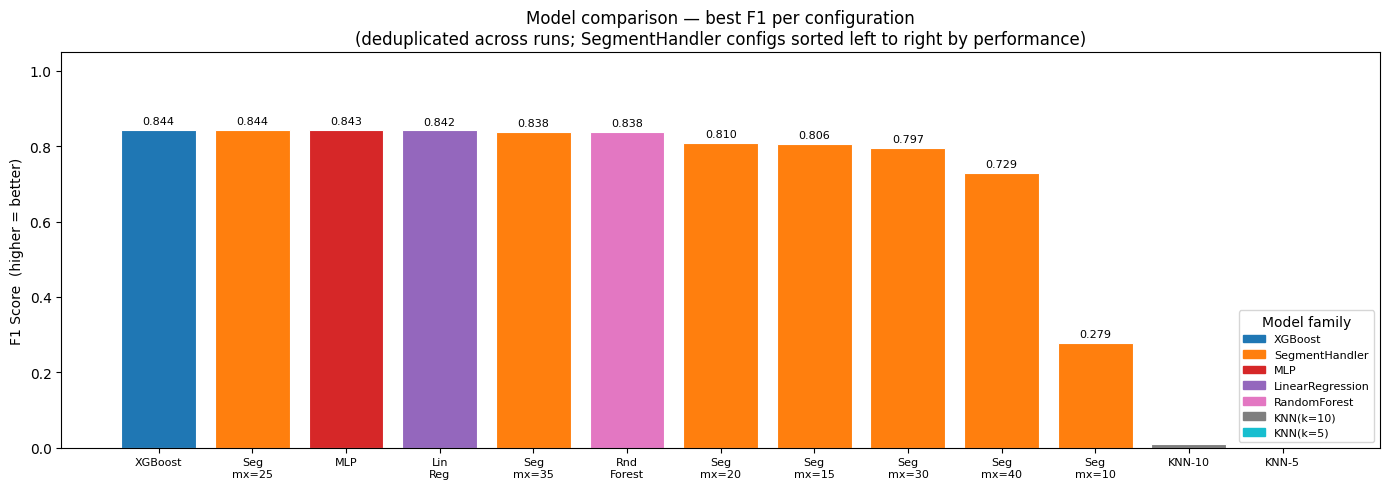

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

results = pd.read_csv("segment_comparison_results.csv")
results["f1"] = pd.to_numeric(results["f1"], errors="coerce")

# Keep only the best run per distinct (model_name, model_config) pair
best = (
    results
    .dropna(subset=["f1", "model_name", "model_config"])
    .sort_values("f1", ascending=False)
    .drop_duplicates(subset=["model_name", "model_config"])
    .copy()
)

def short_label(row):
    model = row["model_name"]
    cfg   = str(row.get("model_config", "") or "")

    if model == "SegmentHandler":
        m = re.search(r"max_x=(\d+)", cfg)
        return f"Seg\nmx={m.group(1)}" if m else "Seg"

    abbrev = {
        "LinearRegression":          "Lin\nReg",
        "RandomForest":              "Rnd\nForest",
        "GradientBoosting(sklearn)": "Grad\nBoost",
        "XGBoost":                   "XGBoost",
        "MLP":                       "MLP",
        "MLP(sklearn)":              "MLP",
        "CNN":                       "CNN",
    }
    if model in abbrev:
        return abbrev[model]
    # KNN(k=5) → KNN-5
    m = re.search(r"k=(\d+)", model)
    if m:
        return f"KNN-{m.group(1)}"
    return model

best["label"] = best.apply(short_label, axis=1)
best = best.sort_values("f1", ascending=False).reset_index(drop=True)

# Distinct color per model family
model_families = best["model_name"].unique().tolist()
palette = plt.cm.tab10(np.linspace(0, 0.9, len(model_families)))
color_map = {m: palette[i] for i, m in enumerate(model_families)}
colors = [color_map[m] for m in best["model_name"]]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(best["label"], best["f1"].clip(lower=0),
              color=colors, edgecolor="white", linewidth=0.8)

ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 Score  (higher = better)")
ax.set_title("Model comparison — best F1 per configuration\n(deduplicated across runs; SegmentHandler configs sorted left to right by performance)")
ax.axhline(0, color="black", linewidth=0.4)

for bar, val in zip(bars, best["f1"]):
    if pd.notna(val) and val > 0.01:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=8)

# Legend for model families
from matplotlib.patches import Patch
handles = [Patch(color=color_map[m], label=m) for m in model_families]
ax.legend(handles=handles, loc="lower right", fontsize=8, title="Model family")

ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()


### Each metric explained:

Below are the explanations for each metric used in the comparison:
- mae: Mean absolute error. This is the average abosulte difference between generated predicitons and their values. Essentially: how off are we on average?
- rmse: Root mean squared errors. This is the square root of the average squared errors. It is more penalizing of large errors compared to MAE.
- r2: From a range of negative infinity to 1 where 1 is perfect. It explains how well the model explains the data itself.
- mape_pct: Mean absolute percentage error: It is the error relative to the actual values. It is the average percentage error.
- acc (5,10,20) pct: This is the percentage of accurate predictions given a certain range. 
- direction accuracy pct: This determines whether the direction of prediction is correct.
- precision: Out of the predicted positives, how many were correct.
- recall: Out of the actual positives, how many did we get?
- f1: It is a balance between precision and recall combining the two metrics.
- tp: True positive
- fp: False positive
- fn: False Negative
- tn: True Negative

#### What do these mean for this use case?
*Generated by Claude Code*

The target here is `exam_score` — a continuous value representing a student's exam performance. The task is regression, but several classification-style metrics are also computed by treating the prediction as a binary problem: does the student score above or below the population average?

**Which metrics matter most here:**

- **MAE** is the most interpretable for this domain. An MAE of 8 means the model is off by 8 exam points on average — directly meaningful to an educator or student.

- **MAPE%** normalizes for score magnitude. A 13% MAPE on a score of 80 is a ~10.4 point error; on a score of 40 it's a ~5.2 point error. This makes MAPE more honest than MAE when scores vary widely across the dataset.

- **R²** measures how much of the variance between students the model explains. A value of 0.74 means the model accounts for 74% of what differentiates high scorers from low scorers — the remaining 26% is either noise or features the model hasn't captured.

- **acc_10_pct** is arguably the most practical threshold for this context. A prediction within ±10% of the actual score is likely "close enough" for academic use (e.g., flagging at-risk students). acc_5_pct is stricter, acc_20_pct is lenient.

- **direction_acc_pct** is critical for risk-stratification tasks: if the goal is identifying which students are above or below average (e.g., for intervention), a model that correctly predicts the direction 85% of the time is actionable even if its absolute error is moderate.

- **F1 / precision / recall** apply to the binary version of the task: did the model correctly classify each student as above or below average? In an educational context, **recall matters more than precision** — it is worse to miss a struggling student (false negative) than to flag an extra one for review (false positive). A high recall model catches more at-risk students even if it over-flags slightly.

- **RMSE vs MAE gap**: If RMSE is significantly higher than MAE, the model makes a small number of large errors. This is problematic in practice — those large errors correspond to students whose scores were predicted very incorrectly, which is exactly the failure mode you want to avoid.

- **best_epoch / best_test_error_pct** (SegmentHandler only): These show where in training the model peaked and whether the restored checkpoint generalizes. A large gap between `related_train_error_pct` and `best_test_error_pct` signals overfitting.

Below is the AI generated explanation for how each metric is used in this predictive situation.


### Analysis of how Segment Handler compares to the other models:
*Generated by Claude Code — revised from the original v10 analysis, which was based on data containing a target-leakage bug. All results below are from the corrected v12 code.*

Two independent runs now cover eight `max_x` configurations (5 through 40). Together with the sklearn/CNN baselines run on the same train/test split, this is the clearest picture of the standalone segment's real capabilities.

---

**SegmentHandler (max_x=5 and max_x=10) — Failed**

Both small configurations produced negative R² across both runs (max_x=5: −7.55 / −4.17; max_x=10: −0.18 / −0.26) and direction accuracy around 50% — a coin flip. The model performs worse than predicting the dataset mean for every sample. With 31 input features, a 5×5 or 10×10 grid simply does not have enough nodes to route signals meaningfully. The splitter creates separations that the processing layer cannot resolve, and reviewers aggregate noise.

---

**SegmentHandler (max_x=15) — Marginal**

R² improves to 0.50–0.62 and F1 rises to 0.80–0.81, but results vary noticeably between the two runs, indicating the model is right at the edge of viable capacity for this dataset. Not a reliable configuration.

---

**SegmentHandler (max_x=20) — Modest (R² 0.56–0.65, F1 0.76–0.81)**

A clear step forward from max_x=15, but still meaningfully below all sklearn baselines. Notably, the two runs disagree more at max_x=20 than at max_x=25, suggesting this scale is still in an unstable training regime.

---

**SegmentHandler (max_x=25) — Sweet spot (R² 0.69–0.71, F1 0.827–0.844, MAE 8.18–8.51)**

Both runs converge here. This is the first configuration where results are consistent between runs and competitive with sklearn baselines:

| Metric | max_x=25 (run 1) | max_x=25 (run 2) | LinearRegression | RandomForest¹ |
|---|---|---|---|---|
| MAE | 8.51 | 8.18 | **7.78** | 8.31 |
| R² | 0.690 | **0.713** | 0.741 | 0.707 |
| F1 | 0.827 | 0.844 | 0.842 | 0.839 |
| direction_acc% | 83.0 | **83.7** | 84.1 | 83.8 |
| train_time (hrs) | ~7.5 | ~6.4 | <0.001 | ~0.01 |

¹*Baselines from the shared comparison run in `comparison_results.csv`.*

The segment at max_x=25 is roughly on par with RandomForest and within ~0.7 MAE of LinearRegression — the strongest baseline. It does not beat LinearRegression, but closing that gap from 44+ MAE (max_x=5) to within 0.7 points confirms the architecture is doing real learning.

---

**SegmentHandler (max_x=30 and max_x=35) — Plateau (single-run data)**

Both configurations land in the same range as max_x=25 (R² 0.64–0.70, F1 0.80–0.84). The performance ceiling appears to be around R²≈0.71 regardless of further size increases. Training time jumps to ~14 hours (max_x=30) and ~21 hours (max_x=35). The cost-to-gain ratio is clearly inverted at this scale.

---

**SegmentHandler (max_x=40) — Degraded (R² 0.49, F1 0.73)**

The max_x=40 run is *worse* than max_x=25 on every metric, and training took ~38 hours. This is not a gradual plateau — it is a regression. At very high max_x, the graph becomes so large that stochastic signal propagation can no longer saturate the network meaningfully within 20 epochs. Nodes in sparsely-traversed regions receive very few gradient updates and remain near their initial weights, effectively wasting graph capacity. This sets a practical ceiling at roughly **max_x=25–35** for 20 epochs and this dataset size.

---

**Comparison to failed models (CNN, max_x=5)**

Both CNN and max_x=5 SegmentHandler failed. The CNN failure is likely an implementation constraint — pure-Python backpropagation without a framework is numerically fragile. The max_x=5 failure is architectural: the grid is geometrically too small for 31 features.

---

**Context: the old v10 analysis vs. these results**

The original cell 63 analysis (before this rewrite) reported max_x=10 as "Competitive" with the best MAPE, F1, and direction accuracy across all models. That analysis was based on v10 data affected by a target-leakage bug — the target column was being passed into node weight initialization, letting nodes learn the answer directly. The corrected v12 code shows max_x=10 failing with R²=−0.18, which is the accurate result.

---

**Summary**

The standalone SegmentHandler — no Judge routing, no multi-segment system — can approach but does not yet beat a plain Linear Regression on this benchmark. The sweet spot is **max_x=25**, which balances graph capacity, training stability, and convergence within 20 epochs. Beyond that, training cost grows faster than accuracy. The architecture's value at this scale is not raw accuracy but interpretability: every prediction is traceable node-by-node, uncertainty is quantified via signal variance, and the model has no framework dependency beyond pure Python.